# Mystery source analysis

This notebook does four things:

1. loads the saved peak-fit table and calibration tables,
2. converts the fitted mystery-source peaks from ADC to energy with propagated uncertainties,
3. reconstructs the saved Gaussian + linear-background fits in **energy space** and plots them,
4. identifies the **highest-amplitude Gaussian** and reports its calibrated energy.

This notebook uses only the quantities already saved in the fit table:
- `fit_xmin`, `fit_xmax`
- `background_slope`, `background_intercept`
- `center_ADC`, `center_ADC_err`
- `sigma_ADC`, `sigma_ADC_err`
- `amplitude_counts_per_s`, `amplitude_counts_per_s_err`

So the plotted curves are the same fitted models as before, just shown on an energy axis.


In [3]:
# -----------------------------
# IMPORTS
# -----------------------------

from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True


In [4]:
# -----------------------------
# FILE PATHS
# -----------------------------

PEAKS_FILE = Path("peak_analysis_outputs") / "manual_peak_fits_all.csv"
BASE_CAL_FILE = Path("calibration_data") / "base_calibration_feb24.csv"
DAILY_ERR_FILE = Path("calibration_data") / "daily_error_adjustments.csv"

for p in [PEAKS_FILE, BASE_CAL_FILE, DAILY_ERR_FILE]:
    print(f"{p}: exists={p.exists()}")

if not PEAKS_FILE.exists():
    raise FileNotFoundError(f"Could not find peak table: {PEAKS_FILE}")
if not BASE_CAL_FILE.exists():
    raise FileNotFoundError(f"Could not find base calibration file: {BASE_CAL_FILE}")
if not DAILY_ERR_FILE.exists():
    raise FileNotFoundError(f"Could not find daily error file: {DAILY_ERR_FILE}")


peak_analysis_outputs/manual_peak_fits_all.csv: exists=True
calibration_data/base_calibration_feb24.csv: exists=True
calibration_data/daily_error_adjustments.csv: exists=True


In [5]:
# -----------------------------
# LOAD TABLES
# -----------------------------

peaks_df = pd.read_csv(PEAKS_FILE)
base_cal_df = pd.read_csv(BASE_CAL_FILE)
daily_err_df = pd.read_csv(DAILY_ERR_FILE)

print("Peak table shape:", peaks_df.shape)
print("Base calibration table:")
display(base_cal_df)

print("Daily error adjustment table:")
display(daily_err_df)


Peak table shape: (138, 18)
Base calibration table:


,preamp,slope,slope_err,offset,offset_err
0,preamp0,1.317572,0.004624,-3.916731,2.043277
1,preamp100,1.825932,0.019079,-15.747695,13.242461


Daily error adjustment table:


,day,preamp,n_points,temp_C_mean,mean_abs_resid_keV,rms_resid_keV,mean_formal_err_keV,extra_sigma_keV,redchi2_base_naive
0,feb26,0,2,22.4,9.508222,11.709149,5.641836,10.260306,2.842786
1,mar3,0,3,22.0,9.838862,15.275663,4.849381,14.485489,4.901898
2,mar5,0,3,21.9,6.093704,8.671232,9.366776,0.000000,0.674812
3,feb26,100,2,22.4,0.977128,1.357705,18.751697,0.000000,0.004936
4,mar3,100,2,22.5,6.550454,6.857201,18.712101,0.000000,0.130133
5,mar5,100,2,21.9,5.720025,6.031281,18.718196,0.000000,0.100371


In [6]:
# -----------------------------
# FIND AVAILABLE MYSTERY FILES
# -----------------------------

mystery_mask = peaks_df["file"].astype(str).str.contains("data/mystery", case=False, na=False)
mystery_files = sorted(peaks_df.loc[mystery_mask, "file"].dropna().unique())

if len(mystery_files) == 0:
    raise RuntimeError("No mystery-source entries were found in the peak table.")

summary = (
    peaks_df.loc[mystery_mask]
    .groupby("file", as_index=False)
    .agg(
        n_peaks=("file", "size"),
        max_amplitude=("amplitude_counts_per_s", "max"),
        mean_center_ADC=("center_ADC", "mean"),
    )
    .sort_values("file")
    .reset_index(drop=True)
)

print("Available mystery spectra:")
display(summary)

for i, f in enumerate(mystery_files):
    print(f"[{i}] {f}")


Available mystery spectra:


,file,n_peaks,max_amplitude,mean_center_ADC
0,data/mystery/mystery_10cmdistance_angle0_pream...,11,14.032203,371.889786
1,data/mystery/mystery_10cmdistance_angle0_pream...,11,25.975884,306.401522
2,data/mystery/mystery_10cmdistance_angle180_pre...,11,18.474536,415.774061
3,data/mystery/mystery_10cmdistance_angle180_pre...,11,25.839731,307.314033
4,data/mystery/mystery_10cmdistance_angle90_prea...,11,8.036644,414.474137
5,data/mystery/mystery_10cmdistance_angle90_prea...,11,11.119660,320.913313


[0] data/mystery/mystery_10cmdistance_angle0_preamp0.csv
[1] data/mystery/mystery_10cmdistance_angle0_preamp100.csv
[2] data/mystery/mystery_10cmdistance_angle180_preamp0.csv
[3] data/mystery/mystery_10cmdistance_angle180_preamp100.csv
[4] data/mystery/mystery_10cmdistance_angle90_preamp0.csv
[5] data/mystery/mystery_10cmdistance_angle90_preamp100.csv


## Choose the mystery spectrum to analyze

Set `TARGET_FILE` to the file you want.  
If you know the measurement day and want to include the saved day-by-day extra calibration uncertainty, set `DAY_LABEL` accordingly (`"feb26"`, `"mar3"`, or `"mar5"` in the current table).  
If the day is unknown, leave `DAY_LABEL = None`; then only the base calibration uncertainty is used.


In [55]:
# -----------------------------
# START: USER CHOICES
# -----------------------------

TARGET_FILE = mystery_files[5]
DAY_LABEL = "mar5"   # e.g. "feb26", "mar3", "mar5", or None if unknown

print("TARGET_FILE =", TARGET_FILE)
print("DAY_LABEL   =", DAY_LABEL)


TARGET_FILE = data/mystery/mystery_10cmdistance_angle90_preamp100.csv
DAY_LABEL   = mar5


In [56]:
# -----------------------------
# HELPER FUNCTIONS
# -----------------------------

def parse_preamp_from_filename(filename):
    m = re.search(r"preamp(\d+)", str(filename))
    if m is None:
        raise ValueError(f"Could not parse preamp from filename: {filename}")
    return int(m.group(1))


def calibration_row_for_preamp(base_cal_df, preamp_value):
    label = f"preamp{int(preamp_value)}"
    sub = base_cal_df.loc[base_cal_df["preamp"].astype(str) == label]
    if len(sub) != 1:
        raise RuntimeError(f"Expected exactly one calibration row for {label}, found {len(sub)}")
    return sub.iloc[0]


def extra_sigma_keV_for_day(daily_err_df, day_label, preamp_value):
    if day_label is None:
        return 0.0

    sub = daily_err_df.loc[
        (daily_err_df["day"].astype(str) == str(day_label)) &
        (daily_err_df["preamp"].astype(int) == int(preamp_value))
    ]

    if len(sub) == 0:
        raise RuntimeError(f"No daily error adjustment found for day={day_label}, preamp={preamp_value}")

    return float(sub.iloc[0]["extra_sigma_keV"])


def adc_to_energy(adc, slope, offset):
    return slope * np.asarray(adc, dtype=float) + offset


def energy_uncertainty_from_adc(adc, adc_err, slope, slope_err, offset_err, extra_sigma_keV=0.0):
    adc = np.asarray(adc, dtype=float)
    adc_err = np.asarray(adc_err, dtype=float)
    var = (
        (adc * float(slope_err)) ** 2
        + (float(slope) * adc_err) ** 2
        + float(offset_err) ** 2
        + float(extra_sigma_keV) ** 2
    )
    return np.sqrt(var)


def gaussian(x, A, mu, sigma):
    sigma = abs(float(sigma))
    return float(A) * np.exp(-((np.asarray(x, dtype=float) - float(mu)) ** 2) / (2 * sigma**2))


def group_model_curve_adc(group_df, npts=800):
    xmin = float(group_df["fit_xmin"].iloc[0])
    xmax = float(group_df["fit_xmax"].iloc[0])
    bg_m = float(group_df["background_slope"].iloc[0])
    bg_b = float(group_df["background_intercept"].iloc[0])

    x = np.linspace(xmin, xmax, int(npts))
    y_bg = bg_m * x + bg_b
    y_total = y_bg.copy()

    peak_curves = []
    for _, row in group_df.sort_values("peak_in_group").iterrows():
        y_peak = gaussian(x, row["amplitude_counts_per_s"], row["center_ADC"], row["sigma_ADC"])
        y_total = y_total + y_peak
        peak_curves.append({
            "peak_in_group": int(row["peak_in_group"]),
            "x_adc": x.copy(),
            "y_peak": y_peak,
        })

    return {
        "group_id": int(group_df["group_id"].iloc[0]),
        "x_adc": x,
        "y_bg": y_bg,
        "y_total": y_total,
        "peak_curves": peak_curves,
    }


In [57]:
# -----------------------------
# SELECT AND CONVERT THE TARGET MYSTERY SPECTRUM
# -----------------------------

mystery_df = peaks_df.loc[peaks_df["file"] == TARGET_FILE].copy()

if len(mystery_df) == 0:
    raise RuntimeError(f"No rows found for TARGET_FILE = {TARGET_FILE}")

mystery_df = mystery_df.sort_values(["group_id", "peak_in_group"]).reset_index(drop=True)

preamp_value = parse_preamp_from_filename(TARGET_FILE)
cal_row = calibration_row_for_preamp(base_cal_df, preamp_value)

slope = float(cal_row["slope"])
slope_err = float(cal_row["slope_err"])
offset = float(cal_row["offset"])
offset_err = float(cal_row["offset_err"])

extra_sigma_keV = extra_sigma_keV_for_day(daily_err_df, DAY_LABEL, preamp_value)

print("Parsed preamp:", preamp_value)
print(f"Using calibration: E = ({slope:.8f} ± {slope_err:.8f}) * ADC + ({offset:.8f} ± {offset_err:.8f}) keV")
print(f"Additional day-by-day calibration term: {extra_sigma_keV:.6f} keV")

mystery_df["energy_keV"] = adc_to_energy(mystery_df["center_ADC"], slope, offset)
mystery_df["energy_err_keV"] = energy_uncertainty_from_adc(
    adc=mystery_df["center_ADC"],
    adc_err=mystery_df["center_ADC_err"],
    slope=slope,
    slope_err=slope_err,
    offset_err=offset_err,
    extra_sigma_keV=extra_sigma_keV,
)

mystery_df["sigma_keV"] = abs(slope) * mystery_df["sigma_ADC"].astype(float)
mystery_df["sigma_err_keV"] = np.sqrt(
    (mystery_df["sigma_ADC"].astype(float) * slope_err) ** 2
    + (abs(slope) * mystery_df["sigma_ADC_err"].astype(float)) ** 2
)

mystery_df["fit_xmin_keV"] = adc_to_energy(mystery_df["fit_xmin"], slope, offset)
mystery_df["fit_xmax_keV"] = adc_to_energy(mystery_df["fit_xmax"], slope, offset)

display_cols = [
    "file",
    "group_id",
    "peak_in_group",
    "center_ADC",
    "center_ADC_err",
    "energy_keV",
    "energy_err_keV",
    "sigma_ADC",
    "sigma_keV",
    "sigma_err_keV",
    "amplitude_counts_per_s",
    "amplitude_counts_per_s_err",
    "fit_xmin_keV",
    "fit_xmax_keV",
]

display(mystery_df[display_cols])


Parsed preamp: 100
Using calibration: E = (1.82593166 ± 0.01907917) * ADC + (-15.74769535 ± 13.24246084) keV
Additional day-by-day calibration term: 0.000000 keV


,file,group_id,peak_in_group,center_ADC,center_ADC_err,energy_keV,energy_err_keV,sigma_ADC,sigma_keV,sigma_err_keV,amplitude_counts_per_s,amplitude_counts_per_s_err,fit_xmin_keV,fit_xmax_keV
0,data/mystery/mystery_10cmdistance_angle90_prea...,1,1,46.332995,1.294520,68.853187,13.480776,6.887394,12.575912,3.184708,2.202422,0.399015,39.030254,1052.422326
1,data/mystery/mystery_10cmdistance_angle90_prea...,1,2,117.500029,1.566251,198.799327,13.731981,47.445062,86.631440,5.270409,11.119660,1.375071,39.030254,1052.422326
2,data/mystery/mystery_10cmdistance_angle90_prea...,1,3,196.791604,1.114435,343.580324,13.914046,9.799243,17.892748,2.456420,2.549590,0.278200,39.030254,1052.422326
3,data/mystery/mystery_10cmdistance_angle90_prea...,1,4,255.935747,0.451656,451.573488,14.138139,0.500000,0.912966,0.449999,2.269079,0.827381,39.030254,1052.422326
4,data/mystery/mystery_10cmdistance_angle90_prea...,1,5,285.821465,13.635886,506.142766,28.723174,55.550868,101.432089,47.666493,3.873849,3.032686,39.030254,1052.422326
5,data/mystery/mystery_10cmdistance_angle90_prea...,1,6,333.129707,0.975758,592.524384,14.796411,8.725571,15.932296,2.221695,3.486031,0.397316,39.030254,1052.422326
6,data/mystery/mystery_10cmdistance_angle90_prea...,1,7,380.290626,15.509777,678.637000,32.093887,10.542459,19.249810,26.191378,0.814111,1.729837,39.030254,1052.422326
7,data/mystery/mystery_10cmdistance_angle90_prea...,1,8,410.694761,18.301932,734.152871,36.790339,14.232961,25.988414,38.355174,1.641227,1.758688,39.030254,1052.422326
8,data/mystery/mystery_10cmdistance_angle90_prea...,1,9,444.660458,30.494057,796.171913,57.858502,17.033540,31.102079,72.437495,1.352568,5.035265,39.030254,1052.422326
9,data/mystery/mystery_10cmdistance_angle90_prea...,1,10,516.727354,19.513546,927.761140,39.269362,26.476446,48.344180,58.640648,2.883762,9.215395,39.030254,1052.422326


## Peak-center summary plot in energy space

This plot shows the fitted peak centers after calibration, with horizontal error bars from the propagated energy uncertainty.
The vertical coordinate is the fitted Gaussian amplitude.


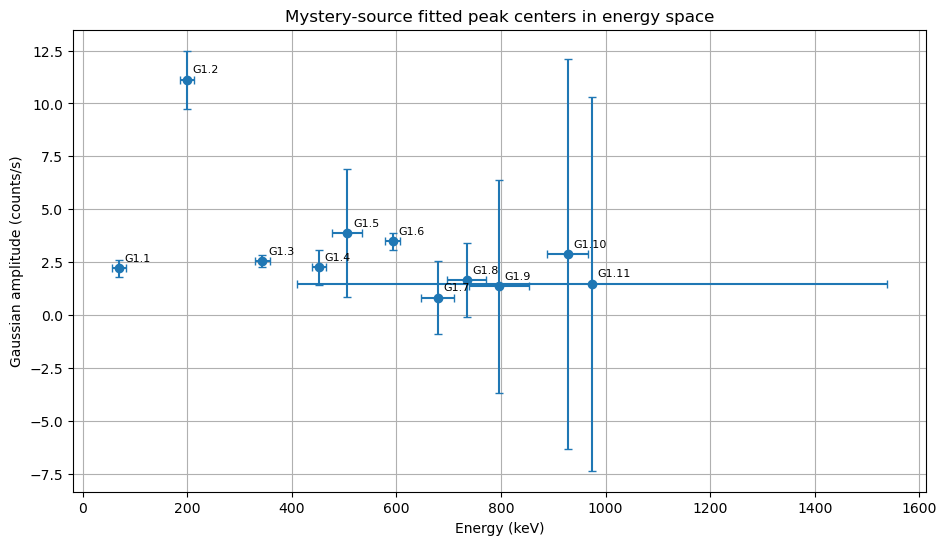

In [58]:
# -----------------------------
# PEAK-CENTER SUMMARY PLOT
# -----------------------------

fig, ax = plt.subplots(figsize=(11, 6))

ax.errorbar(
    mystery_df["energy_keV"],
    mystery_df["amplitude_counts_per_s"],
    xerr=mystery_df["energy_err_keV"],
    yerr=mystery_df["amplitude_counts_per_s_err"],
    fmt="o",
    capsize=3,
)

for _, row in mystery_df.iterrows():
    ax.annotate(
        f"G{int(row['group_id'])}.{int(row['peak_in_group'])}",
        (row["energy_keV"], row["amplitude_counts_per_s"]),
        textcoords="offset points",
        xytext=(4, 5),
        fontsize=8,
    )

ax.set_xlabel("Energy (keV)")
ax.set_ylabel("Gaussian amplitude (counts/s)")
ax.set_title("Mystery-source fitted peak centers in energy space")
plt.show()


## Reconstructed Gaussian fits in energy space

For each fitted group, the notebook reconstructs the saved model

\[
\text{linear background} + \sum \text{Gaussians}
\]

on a dense ADC grid and then maps that grid onto energy using the calibration line.

This preserves the original fit model; only the horizontal axis changes from ADC to energy.


In [59]:
# -----------------------------
# RECONSTRUCT FIT CURVES IN ENERGY SPACE
# -----------------------------

group_models = []
for group_id, group_df in mystery_df.groupby("group_id"):
    model = group_model_curve_adc(group_df)
    model["x_keV"] = adc_to_energy(model["x_adc"], slope, offset)

    peak_curves_keV = []
    for peak_curve in model["peak_curves"]:
        peak_curves_keV.append({
            "peak_in_group": peak_curve["peak_in_group"],
            "x_keV": adc_to_energy(peak_curve["x_adc"], slope, offset),
            "y_peak": peak_curve["y_peak"],
        })

    model["peak_curves_keV"] = peak_curves_keV
    group_models.append(model)

print(f"Built {len(group_models)} reconstructed group models.")


Built 1 reconstructed group models.


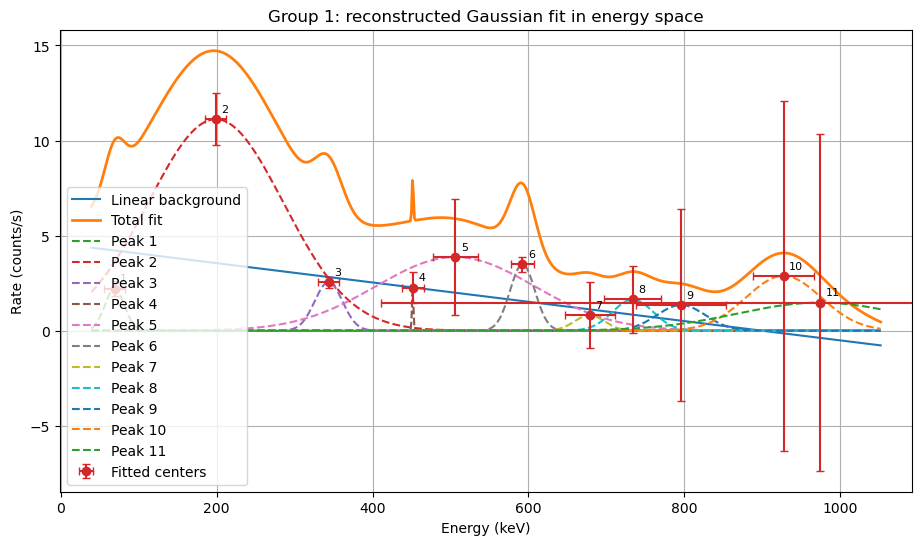

In [60]:
# -----------------------------
# PLOT EACH GROUP IN ENERGY SPACE
# -----------------------------

for model in group_models:
    gid = model["group_id"]
    sub = mystery_df.loc[mystery_df["group_id"] == gid].sort_values("peak_in_group")

    fig, ax = plt.subplots(figsize=(11, 6))

    ax.plot(model["x_keV"], model["y_bg"], label="Linear background")
    ax.plot(model["x_keV"], model["y_total"], linewidth=2, label="Total fit")

    for peak_curve in model["peak_curves_keV"]:
        ax.plot(
            peak_curve["x_keV"],
            peak_curve["y_peak"],
            linestyle="--",
            label=f"Peak {peak_curve['peak_in_group']}",
        )

    ax.errorbar(
        sub["energy_keV"],
        sub["amplitude_counts_per_s"],
        xerr=sub["energy_err_keV"],
        yerr=sub["amplitude_counts_per_s_err"],
        fmt="o",
        capsize=3,
        label="Fitted centers",
    )

    for _, row in sub.iterrows():
        ax.annotate(
            f"{int(row['peak_in_group'])}",
            (row["energy_keV"], row["amplitude_counts_per_s"]),
            textcoords="offset points",
            xytext=(4, 5),
            fontsize=8,
        )

    emin = float(np.min(sub["fit_xmin_keV"]))
    emax = float(np.max(sub["fit_xmax_keV"]))
    pad = 0.04 * (emax - emin if emax > emin else 1.0)
    ax.set_xlim(emin - pad, emax + pad)

    ax.set_xlabel("Energy (keV)")
    ax.set_ylabel("Rate (counts/s)")
    ax.set_title(f"Group {gid}: reconstructed Gaussian fit in energy space")
    ax.legend()
    plt.show()


In [61]:
# -----------------------------
# HIGHEST-AMPLITUDE GAUSSIAN
# -----------------------------

top_peak = mystery_df.sort_values(
    ["amplitude_counts_per_s", "gaussian_area_counts", "energy_keV"],
    ascending=[False, False, True],
).iloc[0]

print("Highest-amplitude fitted Gaussian")
print("--------------------------------")
print("file                   :", top_peak["file"])
print("group_id               :", int(top_peak["group_id"]))
print("peak_in_group          :", int(top_peak["peak_in_group"]))
print(f"center_ADC             : {top_peak['center_ADC']:.6f} ± {top_peak['center_ADC_err']:.6f}")
print(f"energy_keV             : {top_peak['energy_keV']:.6f} ± {top_peak['energy_err_keV']:.6f}")
print(f"sigma_keV              : {top_peak['sigma_keV']:.6f} ± {top_peak['sigma_err_keV']:.6f}")
print(f"amplitude_counts_per_s : {top_peak['amplitude_counts_per_s']:.6f} ± {top_peak['amplitude_counts_per_s_err']:.6f}")


Highest-amplitude fitted Gaussian
--------------------------------
file                   : data/mystery/mystery_10cmdistance_angle90_preamp100.csv
group_id               : 1
peak_in_group          : 2
center_ADC             : 117.500029 ± 1.566251
energy_keV             : 198.799327 ± 13.731981
sigma_keV              : 86.631440 ± 5.270409
amplitude_counts_per_s : 11.119660 ± 1.375071


## Export the converted mystery-peak table

This saves a CSV containing the calibrated mystery-source peaks so that you can compare the strongest line against isotope tables.


In [62]:
# -----------------------------
# SAVE CONVERTED RESULTS
# -----------------------------

output_dir = Path("mystery_analysis_outputs")
output_dir.mkdir(parents=True, exist_ok=True)

safe_name = Path(TARGET_FILE).stem.replace(" ", "_")
output_csv = output_dir / f"{safe_name}_energy_converted_peaks.csv"

mystery_df.to_csv(output_csv, index=False)

print("Saved:", output_csv)


Saved: mystery_analysis_outputs/mystery_10cmdistance_angle90_preamp100_energy_converted_peaks.csv


# Conclusion

Given that this isotope is active and has many decay products, we suspect that this will be in the so-called "island" between Radium and Mendelevium.
Moreover, since our mystery sample is a commecial product and vintage, we suspect that the isotope is both naturally availiable and long-lived--this gives us two possible options to first look at: Th-232 and Uranium ore (which is primarily U-238)

The spectrum for Th-232 is already quite similar in appearance to our spectrum. Moreover the dominant peak in our data is within error in all cases for the Pb-212 decay chain (238.6 keV) and outiside error for the closest peak in uranium ore (340 keV).

The fact that this spectrum is so visibily close as well as within error at its nearest peak suggests that our sample contains Th-232. Indeed, upon research, it may be found that Thorium has been historically added to Kodak cameras in the 40s-50s to increase photo quality (http://archivesgamma.fr/2024/06/06/aero-ektars/).